In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import pickle

2026-03-14 20:08:09.139177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773518889.437796      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773518889.527916      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773518890.247045      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773518890.247101      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773518890.247104      17 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path="/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

cat_path=os.path.join(dataset_path,"Cat")
dog_path=os.path.join(dataset_path,"Dog")

In [3]:
IMG_SIZE=128

data=[]
labels=[]


for file in os.listdir(cat_path)[:10000]:
    try:
        img_path=os.path.join(cat_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(0)
    except:
        pass

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


In [4]:
IMG_SIZE=128


for file in os.listdir(dog_path)[:10000]:
    try:
        img_path=os.path.join(dog_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(1)
    except:
        pass

Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9


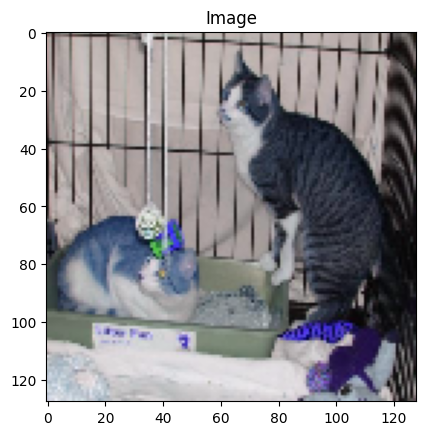

In [5]:
plt.imshow(data[0])
plt.title("Image")
plt.show()

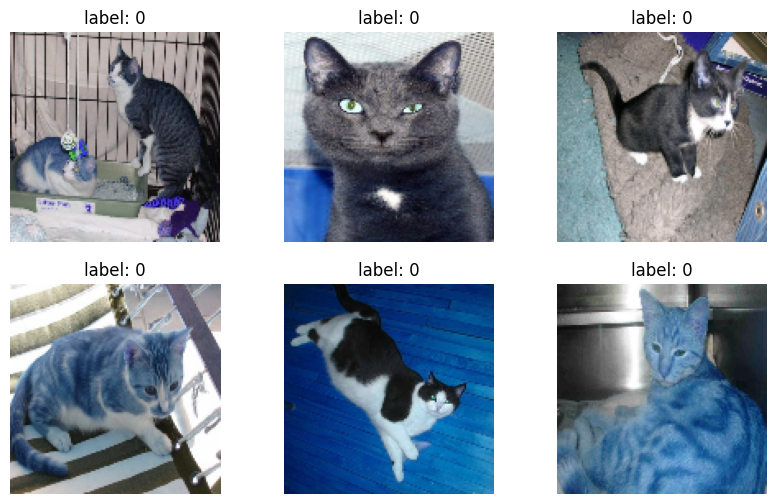

In [6]:
plt.figure(figsize = (10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(data[i])
    plt.title("label: " + str(labels[i]))
    plt.axis("off")

plt.show()

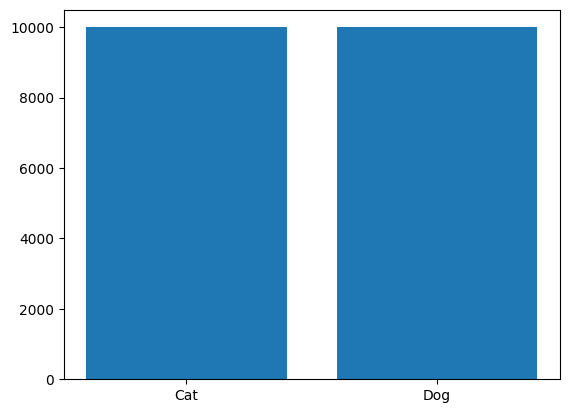

In [7]:
unique, counts=np.unique(labels,return_counts=True)

plt.bar(["Cat","Dog"],counts)
plt.show()

Text(0.5, 1.0, 'Image')

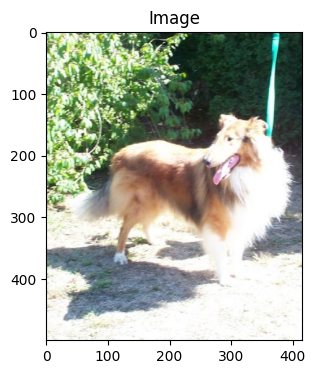

In [8]:
img = cv2.imread(img_path)

plt.figure(figsize = (8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Image")

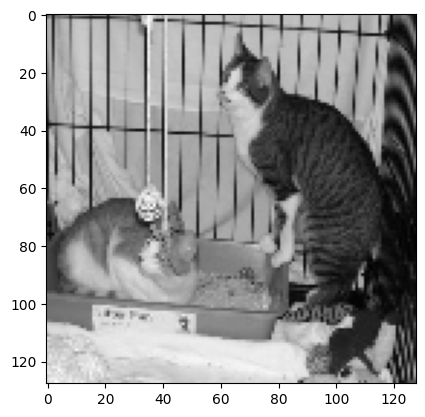

In [9]:
gray=cv2.cvtColor(data[0],cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')
plt.show()

In [10]:
#storing data and labels into arrays so that they can be evaluated
data=np.array(data)/255.0 #normalizing so that all the pixels are in the range of 0 to 1
labels=np.array(labels)

print("Data shape: ",data.shape)
print("Labels shape: ",labels.shape)

Data shape:  (19996, 128, 128, 3)
Labels shape:  (19996,)


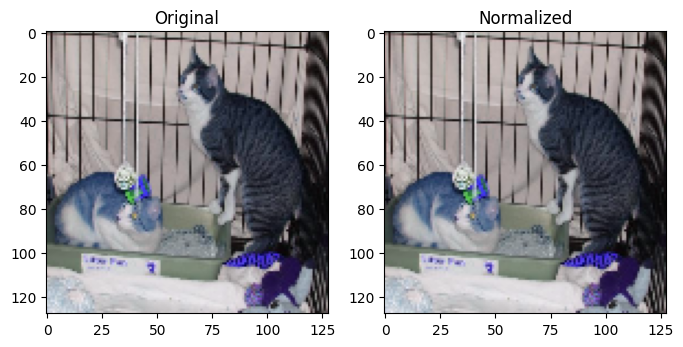

In [11]:
img=data[0]*255
normalized_img=data[0]
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img.astype('uint8'))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(normalized_img)
plt.title("Normalized")

plt.show()

In [12]:
#Although we can't see any diff in the pistures above
#we can see that the value of the pixels have changed:
print("Before normalization: ",img[50][50])
print("After normalization: ",normalized_img[50][50])

Before normalization:  [170. 160. 160.]
After normalization:  [0.66666667 0.62745098 0.62745098]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size = 0.2, random_state = 42
)

In [14]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(15996, 128, 128, 3)
(15996,)
(4000, 128, 128, 3)
(4000,)


In [15]:
model = Sequential()

# 128X128
model.add(Conv2D(32, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 64X64
model.add(Conv2D(64, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 32X32
model.add(Conv2D(128, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 16X16

model.add(Flatten())
model.add(Dense(128, activation= 'relu'))

model.add(Dropout(0.5))

model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-14 20:12:33.384516: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
model.compile(
    optimizer = "adam",
    loss  = "binary_crossentropy",
    metrics = ['accuracy']
)

In [17]:
history = model.fit(
    X_train, y_train, epochs = 5, batch_size = 32, validation_data = ( X_test, y_test)
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 359ms/step - accuracy: 0.5520 - loss: 0.6851 - val_accuracy: 0.7092 - val_loss: 0.5687
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 358ms/step - accuracy: 0.7303 - loss: 0.5356 - val_accuracy: 0.7585 - val_loss: 0.4971
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 182s 365ms/step - accuracy: 0.7878 - loss: 0.4618 - val_accuracy: 0.7997 - val_loss: 0.4312
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 192s 384ms/step - accuracy: 0.8293 - loss: 0.3894 - val_accuracy: 0.8152 - val_loss: 0.4137
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 391ms/step - accuracy: 0.8564 - loss: 0.3360 - val_accuracy: 0.8367 - val_loss: 0.3769


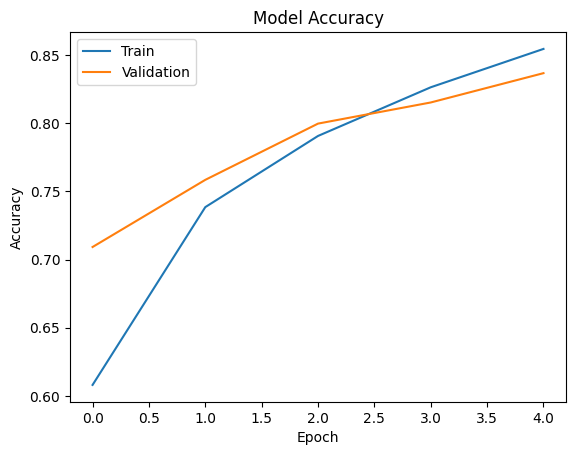

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

In [19]:
model.save("animal_classifier.h5")